In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("fer2013.csv")
print(df.head())
print("Classes:", df['emotion'].unique())
print("Image shape should be 48x48")


   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training
Classes: [0 2 4 6 3 5 1]
Image shape should be 48x48


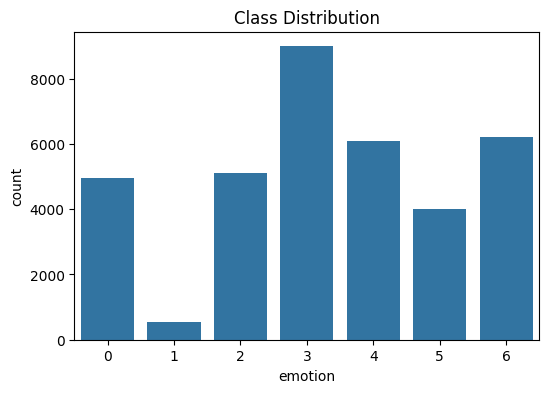

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['emotion'])
plt.title("Class Distribution")
plt.show()

In [ ]:
def preprocess_data(df):
    pixels = df['pixels'].tolist()
    images = []
    for pixel_sequence in pixels:
        image = np.array(pixel_sequence.split(), dtype='float32')
        image = image.reshape(48, 48, 1)
        images.append(image)
    return np.array(images)

X = preprocess_data(df)
X = X / 255.0  # normalize
y = to_categorical(df['emotion'], num_classes=7)

print(X.shape, y.shape)

(35887, 48, 48, 1) (35887, 7)


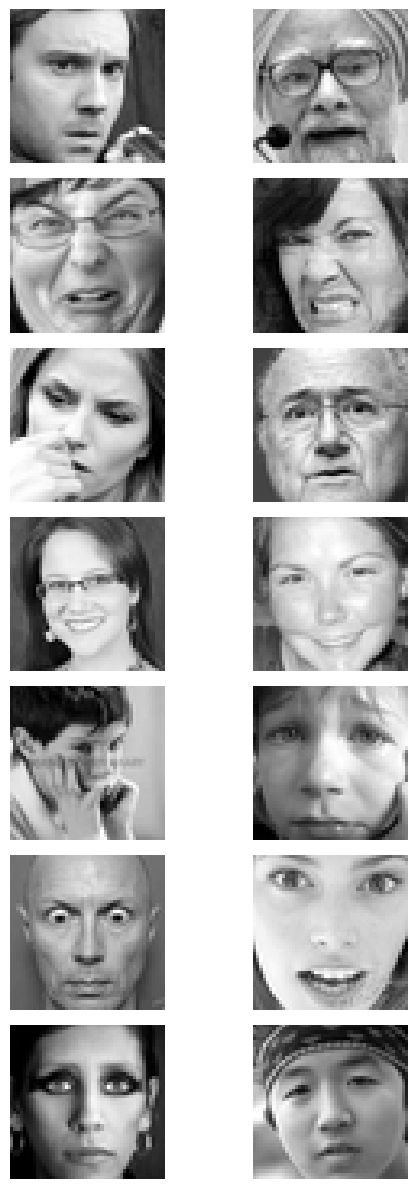

In [ ]:
fig, axes = plt.subplots(7, 2, figsize=(6,12))

for i in range(7):
    samples = df[df['emotion'] == i].head(2)

    for j in range(2):
        pixel_string = samples.iloc[j]['pixels']
        image = np.array(pixel_string.split(), dtype='float32').reshape(48,48)

        axes[i,j].imshow(image, cmap='gray')
        axes[i,j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
X_train = X[df['Usage']=="Training"]
y_train = y[df['Usage']=="Training"]

X_val = X[df['Usage']=="PublicTest"]
y_val = y[df['Usage']=="PublicTest"]

X_test = X[df['Usage']=="PrivateTest"]
y_test = y[df['Usage']=="PrivateTest"]

TASK B — CNN FROM SCRATCH

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_val, y_val)
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


898/898 ━━━━━━━━━━━━━━━━━━━━ 122s 133ms/step - accuracy: 0.2311 - loss: 1.8485 - val_accuracy: 0.2491 - val_loss: 1.8377
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 120s 134ms/step - accuracy: 0.2522 - loss: 1.8024 - val_accuracy: 0.3282 - val_loss: 1.7354
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 122s 136ms/step - accuracy: 0.2959 - loss: 1.7364 - val_accuracy: 0.3820 - val_loss: 1.6464
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 120s 134ms/step - accuracy: 0.3397 - loss: 1.6768 - val_accuracy: 0.4029 - val_loss: 1.5993
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 122s 135ms/step - accuracy: 0.3586 - loss: 1.6377 - val_accuracy: 0.4202 - val_loss: 1.5382
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.3761 - loss: 1.5986 - val_accuracy: 0.4333 - val_loss: 1.5073
Epoch 7/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - accuracy: 0.3979 - loss: 1.5695 - val_accuracy: 0.4458 - val_loss: 1.4716
Epoch 8/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 119s 133ms/step - accuracy: 0.4008 - loss: 1.54

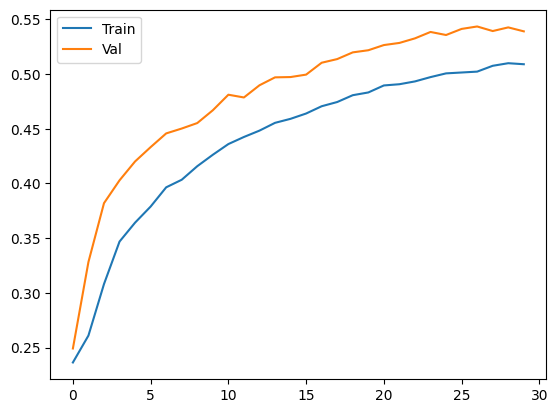

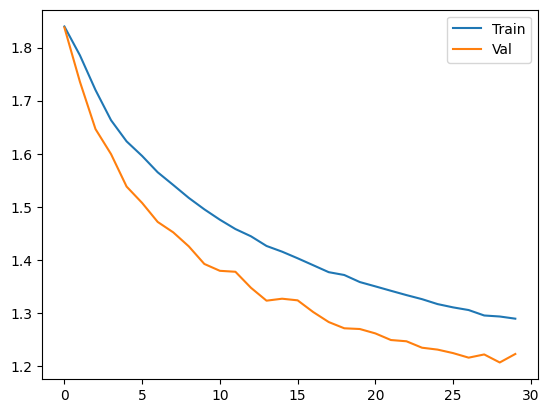

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.show()

113/113 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.5497 - loss: 1.1874
Test Accuracy: 0.5483421683311462
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
              precision    recall  f1-score   support

           0       0.46      0.39      0.43       491
           1       0.00      0.00      0.00        55
           2       0.34      0.22      0.27       528
           3       0.75      0.83      0.79       879
           4       0.46      0.38      0.42       594
           5       0.52      0.81      0.64       416
           6       0.50      0.58      0.54       626

    accuracy                           0.55      3589
   macro avg       0.43      0.46      0.44      3589
weighted avg       0.52      0.55      0.53      3589



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


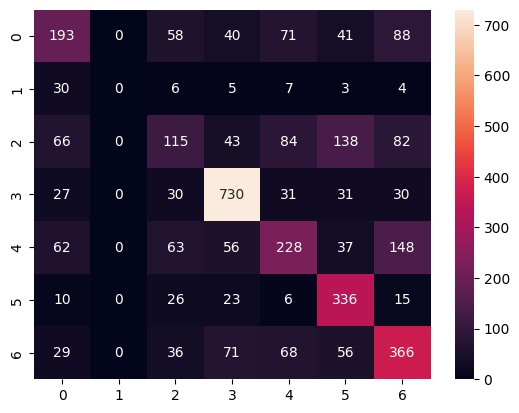

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted Emotion: Surprise


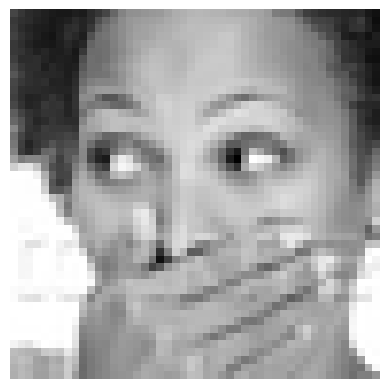

In [ ]:
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

index = np.random.randint(0, len(X_test))
image = X_test[index]

plt.imshow(image.reshape(48,48), cmap='gray')
plt.axis('off')

prediction = model.predict(image.reshape(1,48,48,1))
print("Predicted Emotion:", emotion_labels[np.argmax(prediction)])

In [ ]:
import tensorflow as tf

def convert_to_rgb(images):
    images = tf.image.resize(images, (96, 96))
    images = tf.image.grayscale_to_rgb(images)
    return images

X_train_rgb = convert_to_rgb(X_train)
X_val_rgb   = convert_to_rgb(X_val)
X_test_rgb  = convert_to_rgb(X_test)

print(X_train_rgb.shape)

(28709, 96, 96, 3)


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [ ]:
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(7, activation='softmax')(x)

model_tl = Model(inputs=base_model.input, outputs=outputs)


In [ ]:
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_tl = model_tl.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 239s 513ms/step - accuracy: 0.2414 - loss: 2.0747 - val_accuracy: 0.3884 - val_loss: 1.6119
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 251s 488ms/step - accuracy: 0.3532 - loss: 1.6533 - val_accuracy: 0.4124 - val_loss: 1.5345
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 275s 518ms/step - accuracy: 0.3893 - loss: 1.5786 - val_accuracy: 0.4283 - val_loss: 1.4982
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 219s 488ms/step - accuracy: 0.4091 - loss: 1.5388 - val_accuracy: 0.4302 - val_loss: 1.4694
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 281s 531ms/step - accuracy: 0.4239 - loss: 1.5071 - val_accuracy: 0.4405 - val_loss: 1.4450
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 216s 482ms/step - accuracy: 0.4380 - loss: 1.4730 - val_accuracy: 0.4450 - val_loss: 1.4314
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 232s 516ms/step - accuracy: 0.4442 - loss: 1.4539 - val_accuracy: 0.4508 - val_loss: 1.4174
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 235s 524ms/step - accuracy: 0.4554 -

In [ ]:
test_loss, test_acc = model_tl.evaluate(X_test_rgb, y_test)
print("Test Accuracy (MobileNet):", test_acc)


113/113 ━━━━━━━━━━━━━━━━━━━━ 25s 219ms/step - accuracy: 0.4626 - loss: 1.4088
Test Accuracy (MobileNet): 0.4786848723888397


113/113 ━━━━━━━━━━━━━━━━━━━━ 24s 204ms/step


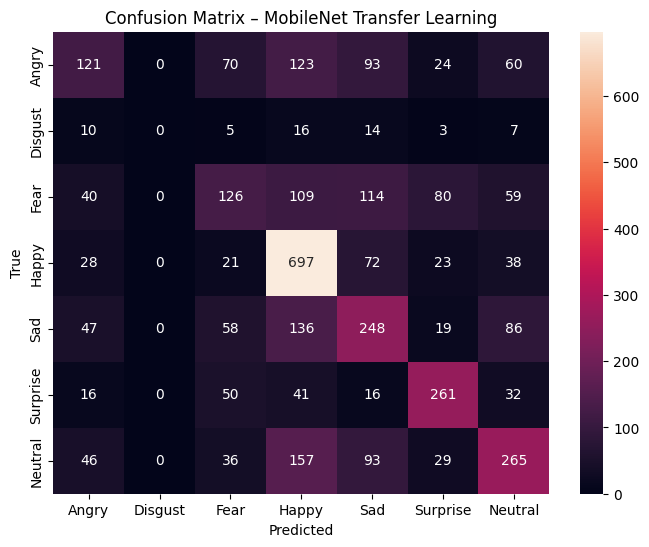

In [ ]:
y_pred = np.argmax(model_tl.predict(X_test_rgb), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=emotion_labels,
            yticklabels=emotion_labels)
plt.title("Confusion Matrix – MobileNet Transfer Learning")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


Custom Head

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = model_tl.fit(
    X_train_rgb, y_train,
    epochs=5,
    valida
    tion_data=(X_val_rgb, y_val),
    batch_size=32
)

Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 398s 427ms/step - accuracy: 0.4759 - loss: 1.3747 - val_accuracy: 0.4798 - val_loss: 1.3255
Epoch 2/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 355s 396ms/step - accuracy: 0.5057 - loss: 1.3132 - val_accuracy: 0.4896 - val_loss: 1.2936
Epoch 3/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 355s 395ms/step - accuracy: 0.5221 - loss: 1.2539 - val_accuracy: 0.5096 - val_loss: 1.2740
Epoch 4/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 356s 397ms/step - accuracy: 0.5407 - loss: 1.2137 - val_accuracy: 0.5219 - val_loss: 1.2560
Epoch 5/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 381s 396ms/step - accuracy: 0.5562 - loss: 1.1731 - val_accuracy: 0.5330 - val_loss: 1.2425


TASK D — HOG + PCA + SVM

In [ ]:
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

HOG Extraction

In [ ]:
def extract_hog(images):
    features = []
    for img in images:
        fd = hog(img.reshape(48,48),
                 orientations=9,
                 pixels_per_cell=(8,8),
                 cells_per_block=(2,2),
                 block_norm='L2-Hys')
        features.append(fd)
    return np.array(features)

X_train_hog = extract_hog(X_train)
X_val_hog = extract_hog(X_val)

PCA + SVM

In [ ]:
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train_hog)
X_val_pca = pca.transform(X_val_hog)

svm = SVC(C=10, kernel='rbf')
svm.fit(X_train_pca, np.argmax(y_train, axis=1))

y_val_pred = svm.predict(X_val_pca)

print("Validation Acc:", accuracy_score(np.argmax(y_val,1), y_val_pred))
print("Macro F1:", f1_score(np.argmax(y_val,1), y_val_pred, average='macro'))

Validation Acc: 0.5734187796043466
Macro F1: 0.573843531009856


LBP

In [ ]:
from skimage.feature import local_binary_pattern

def extract_lbp(images):
    features = []
    for img in images:
        lbp = local_binary_pattern(img.reshape(48,48), P=8, R=1)
        hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0,256))
        features.append(hist)
    return np.array(features)

TASK E — Misclassified Images

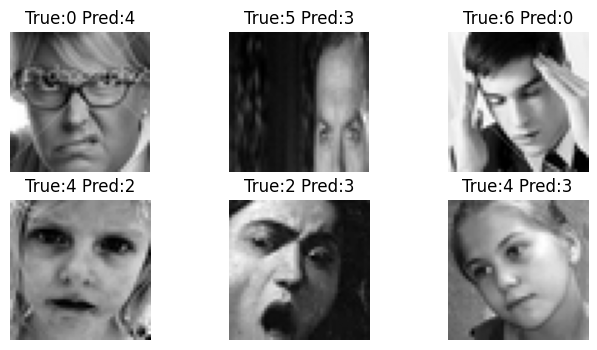

In [ ]:
mis_idx = np.where(y_pred != y_true)[0][:6]

plt.figure(figsize=(8,4))
for i, idx in enumerate(mis_idx):
    plt.subplot(2,3,i+1)
    plt.imshow(X_test[idx].reshape(48,48), cmap='gray')
    plt.title(f"True:{y_true[idx]} Pred:{y_pred[idx]}")
    plt.axis('off')
plt.show()